# Agregación y agrupamiento de datos

Objetivo: Los estudiantes explorarán la disponibilidad de propiedades en su ciudad, detectando cuáles son las zonas con mayor oferta y ocupación.

In [3]:
# Primero importamos la librería pandas para poder trabajar con dataframes
import pandas as pd 

In [4]:
# Después leemos el archivo CSV que contiene los datos de Airbnb en Boston y lo almacenamos en un dataframe llamado "airbnb"
airbnb = pd.read_csv("Datos_limpios_Boston.csv")
airbnb.head()

,Unnamed: 0,last_scraped,source,name,host_name,host_location,host_about,host_is_superhost,host_has_profile_pic,host_identity_verified,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,0,2026-06-16,city scrape,King Bed Loft in the Heart of Downtown Boston,Lu,"Boston, MA",We like our spaces clean and clutter free and ...,t,t,t,...,5.00,4.97,4.99,4.89,4.84,1.0,1.0,0.0,0.0,4.77
1,1,2026-06-16,city scrape,Super 2 Bedroom apt in Beacon Hill Boston,Lilith,"Boston, MA",Teacher,f,t,t,...,4.75,5.00,5.00,5.00,5.00,7.0,2.0,0.0,0.0,0.11
2,2,2026-06-16,city scrape,Serene Studio in a Perfect Location,Kristina,"Boston, MA",We have lived in our 1868 Victorian for over 2...,t,t,t,...,4.92,4.96,4.97,4.92,4.81,2.0,2.0,0.0,0.0,3.33
3,3,2026-06-16,city scrape,Spacious 1br In Boston FIDI | Close to T!,Healing Homes,"Boston, MA",Healing Homes of Boston's mission it to provid...,f,t,t,...,4.86,4.91,4.91,4.91,4.63,43.0,2.0,0.0,0.0,4.21
4,4,2026-06-16,city scrape,Exquisite 3Bedroom Apt with in Beacon Hill,Lilith,"Boston, MA",Teacher,f,t,t,...,5.00,5.00,4.90,5.00,4.70,7.0,2.0,0.0,0.0,0.09


▹ ¿Cuáles son los barrios con más alojamientos disponibles en los próximos 30 días? Usar ‘neighbourhood_cleansed’

In [ ]:
# Aquí lo que hicimos fue agrupar los datos por la columna "neighbourhood_cleansed" y luego calcular la suma de la disponibilidad total y el número de alojamientos en cada barrio.
# Finalmente, ordenamos los resultados por la disponibilidad total en orden descendente.
df_avail = (
    airbnb
    .groupby("neighbourhood_cleansed")
    .agg(
        disponibilidad_total=("availability_30", "sum"),
        alojamientos=("availability_30", "size")
    )
    .sort_values(
        "disponibilidad_total",
        ascending=False
    )
)

df_avail.head(10)

,disponibilidad_total,alojamientos
neighbourhood_cleansed,,
Dorchester,6936,533
Brighton,3876,254
Back Bay,3683,269
Roxbury,3604,274
South End,3420,240
Downtown,2910,282
East Boston,2730,194
Fenway,2484,193
South Boston,2277,146


**Los barrios con mayor disponibilidad de alojamientos en los próximos 30 días son los que aparecen en las primeras filas de la tabla. Esto significa que concentran la mayor cantidad de noches disponibles.**

▹ ¿Qué porcentaje de alojamientos están completamente ocupados (0 disponibilidad en 30 días)?

In [ ]:
# Aquí calculamos el porcentaje de alojamientos que están completamente ocupados, es decir, aquellos que tienen disponibilidad igual a 0 en los próximos 30 días.
porcentaje = (airbnb["availability_30"] == 0).mean() * 100

print(
    f"El {porcentaje:.2f}% de los alojamientos "
    "están completamente ocupados."
)

El 15.53% de los alojamientos están completamente ocupados.


▹ ¿Los alojamientos más caros tienen mejores reseñas?

In [ ]:
# Aquí agrupamos los datos por la columna "price" y calculamos el promedio de las calificaciones de los alojamientos en cada rango de precio.
df_review_price = (
    airbnb
    .groupby("price")["review_scores_rating"]
    .mean()
    .reset_index()
    .sort_values("price", ascending=False)
)

# Imprimimos las primeras 20 filas del dataframe resultante para ver los resultados.
df_review_price.head(20)

,price,review_scores_rating
2327,828.49,4.750000
2326,827.67,4.990000
2325,825.93,4.920000
2324,825.07,4.980000
2323,822.00,4.940000
2322,821.43,4.800000
2321,817.37,4.900000
2320,816.73,4.800000
2319,814.33,4.970000
2318,812.00,4.950000


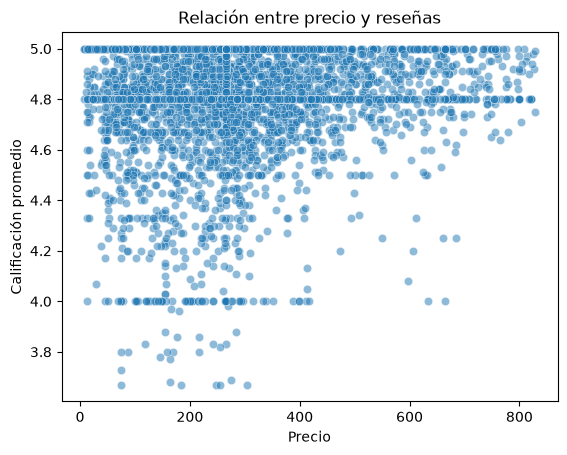

In [ ]:
# Primero importamos las librerías necesarias para crear un gráfico de dispersión.
import seaborn as sns
import matplotlib.pyplot as plt

# Aquí creamos un gráfico de dispersión que muestra la relación entre el precio y la calificación promedio de los alojamientos en Boston.
sns.scatterplot(
    data=airbnb,
    x="price",
    y="review_scores_rating",
    alpha=0.5
)

# Aquí agregamos etiquetas a los ejes y un título al gráfico para que sea más fácil de entender.
plt.xlabel("Precio")
plt.ylabel("Calificación promedio")
plt.title("Relación entre precio y reseñas")
plt.show()

**Los alojamientos más caros no necesariamente tienen mejores reseñas. El precio por sí solo no garantiza una calificación más alta, ya que también influyen la ubicación, el tipo de alojamiento, la limpieza y la atención del anfitrión. Para comprobarlo, se compara el precio con review_scores_rating mediante la tabla y la gráfica.**

▹ Relación entre número de reseñas y calificación promedio

In [ ]:
# Aquí agrupamos los datos por la columna "number_of_reviews" y calculamos el promedio de las calificaciones de los alojamientos en cada rango de número de reseñas.
df_review_count = (
    airbnb
    .groupby("number_of_reviews")["review_scores_rating"]
    .mean()
    .reset_index()
    .sort_values(
        by="number_of_reviews",
        ascending=False
    )
)

# Imprimimos las primeras 20 filas del dataframe resultante para ver los resultados, pero le podemos cambiar el número de filas a mostrar según lo que necesitemos.

df_review_count.head(20)

,number_of_reviews,review_scores_rating
200,204.0,4.670000
199,203.0,4.760000
198,202.0,4.836667
197,201.0,4.890000
196,200.0,4.830000
195,199.0,4.642500
194,198.0,4.820000
193,197.0,4.915000
192,196.0,4.670000
191,194.0,4.890000


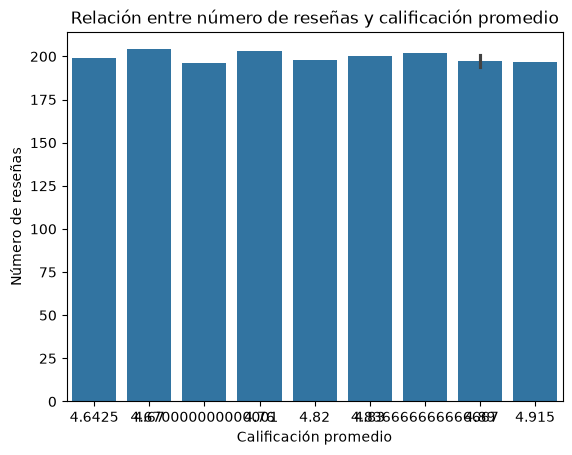

In [ ]:
# Aquí creamos un gráfico de barras que muestra la relación entre el número de reseñas y la calificación promedio de los alojamientos.
sns.barplot(
    data=df_review_count.head(10),
    x="review_scores_rating",
    y="number_of_reviews"
)

plt.xlabel("Calificación promedio")
plt.ylabel("Número de reseñas")
plt.title("Relación entre número de reseñas y calificación promedio")
plt.show()

**La cantidad de reseñas no determina necesariamente una mejor calificación. Aunque algunos alojamientos tienen muchas reseñas y buenas puntuaciones, también puede haber alojamientos con pocas reseñas y calificaciones similares o incluso superiores.**

**En la gráfica de los 10 grupos con mayor número de reseñas, las calificaciones promedio son muy similares. Por ello, no se observa una relación directa entre tener más reseñas y obtener una mejor calificación. La cantidad de reseñas indica la popularidad del alojamiento, pero no garantiza una mayor satisfacción de los huéspedes.**